# Cross-Dataset Model Analysis (H-CAST Baseline Style)

This notebook mirrors the structure of `hcast_analysis.ipynb`, but compares **models** across **datasets**.

It includes:
- per-dataset validation curves (`FPA`, `wAP`, `TICE`, `AHD`),
- per-dataset training loss curves,
- per-level training/validation curves,
- final test comparison tables.


In [121]:
from pathlib import Path
import sys

cwd = Path.cwd().resolve()
repo_root = cwd if (cwd / 'configs').exists() else cwd.parent
notebook_utils_dir = repo_root / 'notebooks'
if str(notebook_utils_dir) not in sys.path:
    sys.path.insert(0, str(notebook_utils_dir))

from model_comparison_utils import (
    ModelComparisonAnalysis,
    ModelComparisonConfig,
    build_model_dataset_run_specs,
    resolve_project_root,
)

PROJECT_ROOT = resolve_project_root()
OUTPUTS_ROOT = Path('/scratch/g.saggini1/outputs')
print(f'Using project root: {PROJECT_ROOT}')


Using project root: /home/g.saggini1/lexicographic_deep_learning_detailed_study


In [122]:
# -------- Configuration --------
OUTPUT_ROOT = OUTPUTS_ROOT

MODEL_COLORS = {
    'hcast': '#1f77b4',
    'hrn': '#ff7f0e',
    'ht_capsnet': '#2ca02c',
    'lhdnn': '#d62728',
    'hiercos': '#cad627',
}

# Manual mode: choose run-name tokens here; runs are searched as {model}_{dataset}.
AUTO_DISCOVER = False
DATASET_NAMES = ['cifar-100', 'cub-200-2011', 'fgvc-aircraft', 'inat19']  # cifar-100, cub-200-2011, fgvc-aircraft, inat19
MODEL_NAMES = ['hcast', 'lhdnn', 'hrn', 'ht_capsnet', 'hiercos']       # hcast, lhdnn, hrn, ht_capsnet, hiercos

MODEL_RUN_NAMES = {
    'ht_capsnet': 'capsnet',
}
DATASET_RUN_NAMES = {
    'inat19': 'inat19',
}
MODEL_LABELS = {
    'hcast': 'H-CAST',
    'hrn': 'HRN',
    'ht_capsnet': 'HT-CapsNet',
    'lhdnn': 'LH-DNN',
    'hiercos': 'HierCoS',
}
DATASET_LABELS = {}
RUN_NAME_OVERRIDES = {}
RUN_LABEL_OVERRIDES = {}
RUN_COLOR_OVERRIDES = {}
EXTRA_RUNS = [
    'hiercos_cub200_global_softmax_ce_reg_baseline_kl_leaf'
]

MANUAL_RUNS = build_model_dataset_run_specs(
    MODEL_NAMES,
    DATASET_NAMES,
    model_run_names=MODEL_RUN_NAMES,
    dataset_run_names=DATASET_RUN_NAMES,
    model_labels=MODEL_LABELS,
    dataset_labels=DATASET_LABELS,
    run_name_overrides=RUN_NAME_OVERRIDES,
    run_label_overrides=RUN_LABEL_OVERRIDES,
    run_color_overrides=RUN_COLOR_OVERRIDES,
) + EXTRA_RUNS
MANUAL_RUN_DIRS = []  # Path-only shorthand kept for quick ad hoc additions.

# Optional filters (leave empty = keep everything)
INCLUDE_MODELS = []   # hcast, hrn, ht_capsnet, lhdnn, hiercos
INCLUDE_DATASETS = []  # DATASET_NAMES already selects datasets in manual mode.
INCLUDE_RUN_NAME_SUBSTRINGS = []
EXCLUDE_RUN_NAME_SUBSTRINGS = []

# Use this only when auto-discovering base runs named as model_dataset.
REQUIRE_MODEL_DATASET_RUN_NAME_FORMAT = False

PREFERRED_DATASET_ORDER = ['cifar-100', 'cub-200-2011', 'fgvc-aircraft', 'inat19']
PREFERRED_MODEL_ORDER = ['hcast', 'lhdnn', 'hrn', 'ht_capsnet', 'hiercos']


In [123]:
config = ModelComparisonConfig(
    output_root=OUTPUT_ROOT,
    auto_discover=AUTO_DISCOVER,
    manual_runs=MANUAL_RUNS,
    manual_run_dirs=MANUAL_RUN_DIRS,
    include_models=INCLUDE_MODELS,
    include_datasets=INCLUDE_DATASETS,
    include_run_name_substrings=INCLUDE_RUN_NAME_SUBSTRINGS,
    exclude_run_name_substrings=EXCLUDE_RUN_NAME_SUBSTRINGS,
    require_model_dataset_run_name_format=REQUIRE_MODEL_DATASET_RUN_NAME_FORMAT,
    preferred_dataset_order=PREFERRED_DATASET_ORDER,
    preferred_model_order=PREFERRED_MODEL_ORDER,
    model_colors=MODEL_COLORS,
)

analysis = ModelComparisonAnalysis.from_config(config)
analysis.print_run_summary()


Skipping missing/manual-invalid run: /scratch/g.saggini1/outputs/hiercos_cifar100
Skipping missing/manual-invalid run: /scratch/g.saggini1/outputs/hiercos_cub200
Skipping missing/manual-invalid run: /scratch/g.saggini1/outputs/lhdnn_aircraft
Skipping missing/manual-invalid run: /scratch/g.saggini1/outputs/capsnet_aircraft
Skipping missing/manual-invalid run: /scratch/g.saggini1/outputs/hiercos_aircraft
Skipping missing/manual-invalid run: /scratch/g.saggini1/outputs/hcast_inat19
Skipping missing/manual-invalid run: /scratch/g.saggini1/outputs/lhdnn_inat19
Skipping missing/manual-invalid run: /scratch/g.saggini1/outputs/hrn_inat19
Skipping missing/manual-invalid run: /scratch/g.saggini1/outputs/capsnet_inat19
Skipping missing/manual-invalid run: /scratch/g.saggini1/outputs/hiercos_inat19
Candidate run directories: 11
Parsed runs: 11
Filtered runs: 11

Selected runs
-------------
CIFAR-100
  - H-CAST       | run=hcast_cifar100                      | best_td=93/0.7522    | best_ind=93/0.7

## Validation Metrics Curves (Per Dataset)

Interpretation note:
- For `FPA` and `wAP`, higher is better.
- For `TICE` and `AHD`, lower is better.
- Solid lines are top-down metrics; dashed lines are independent metrics.


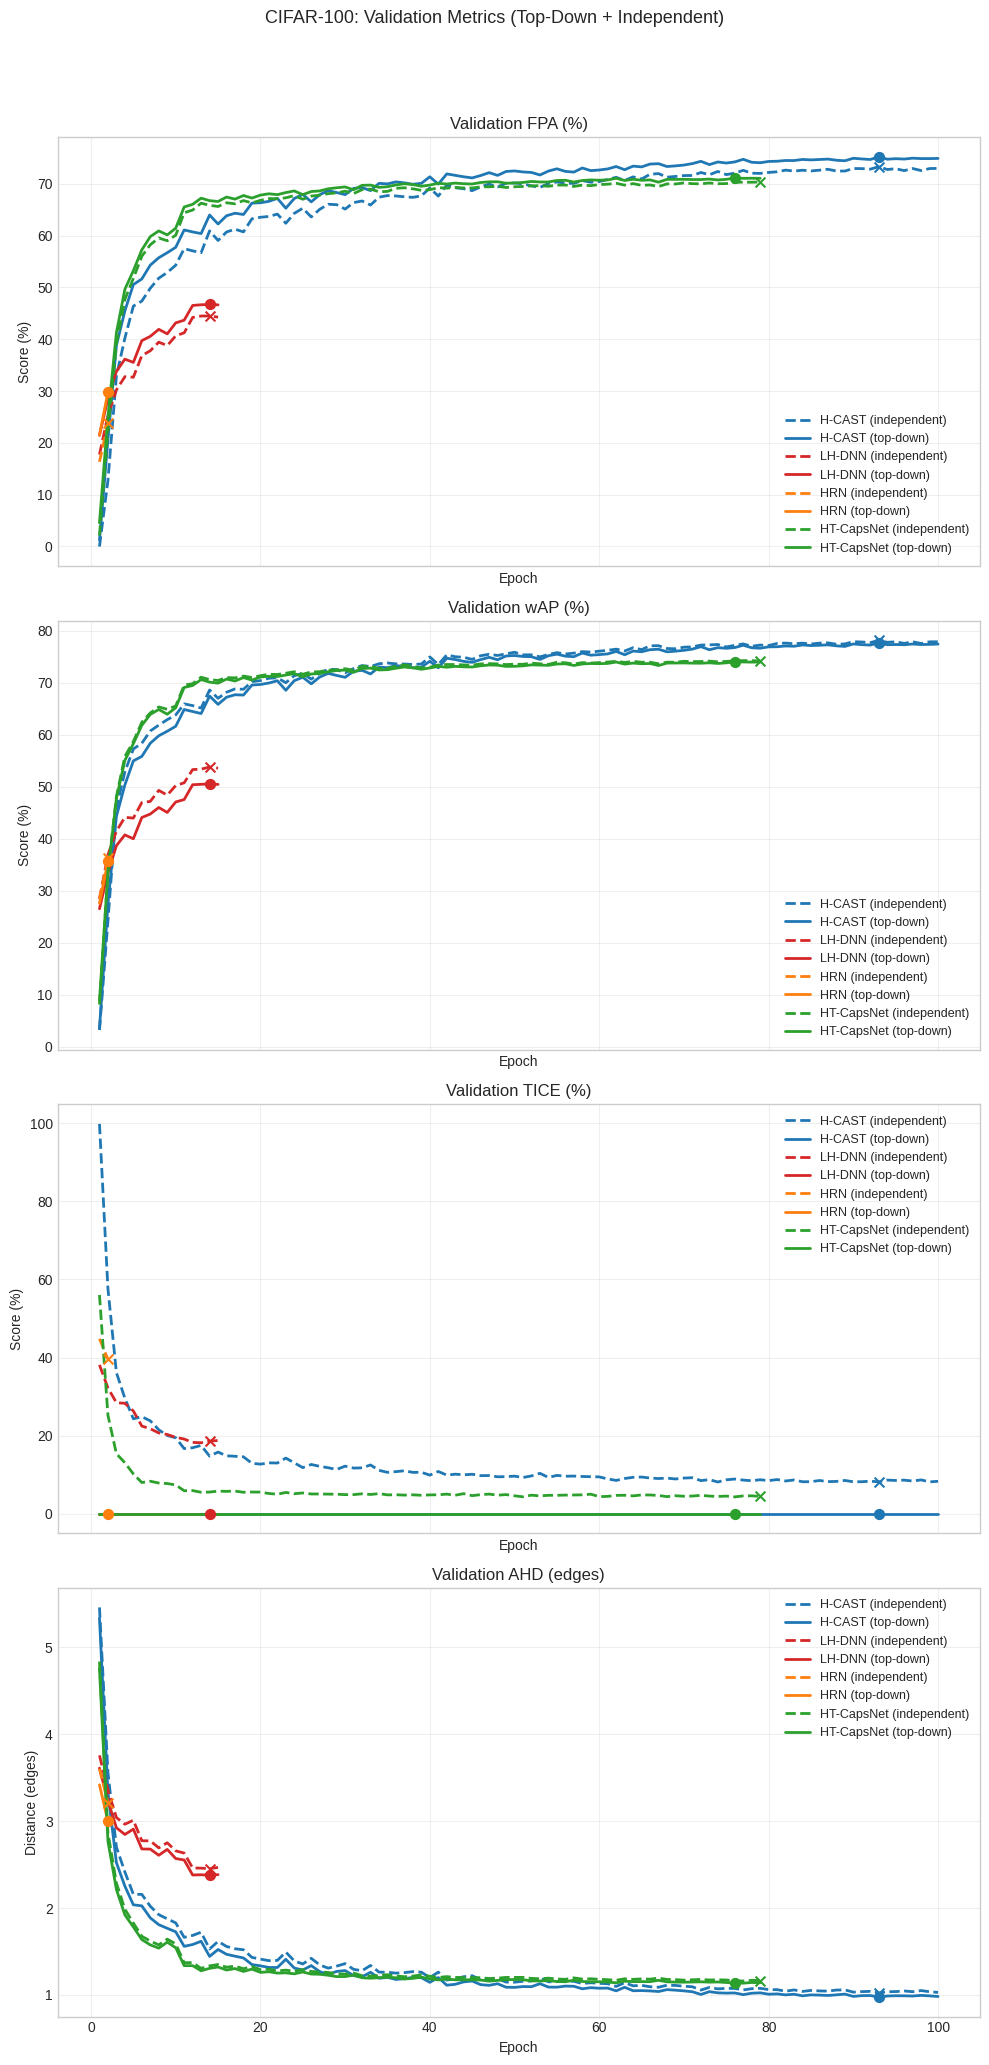

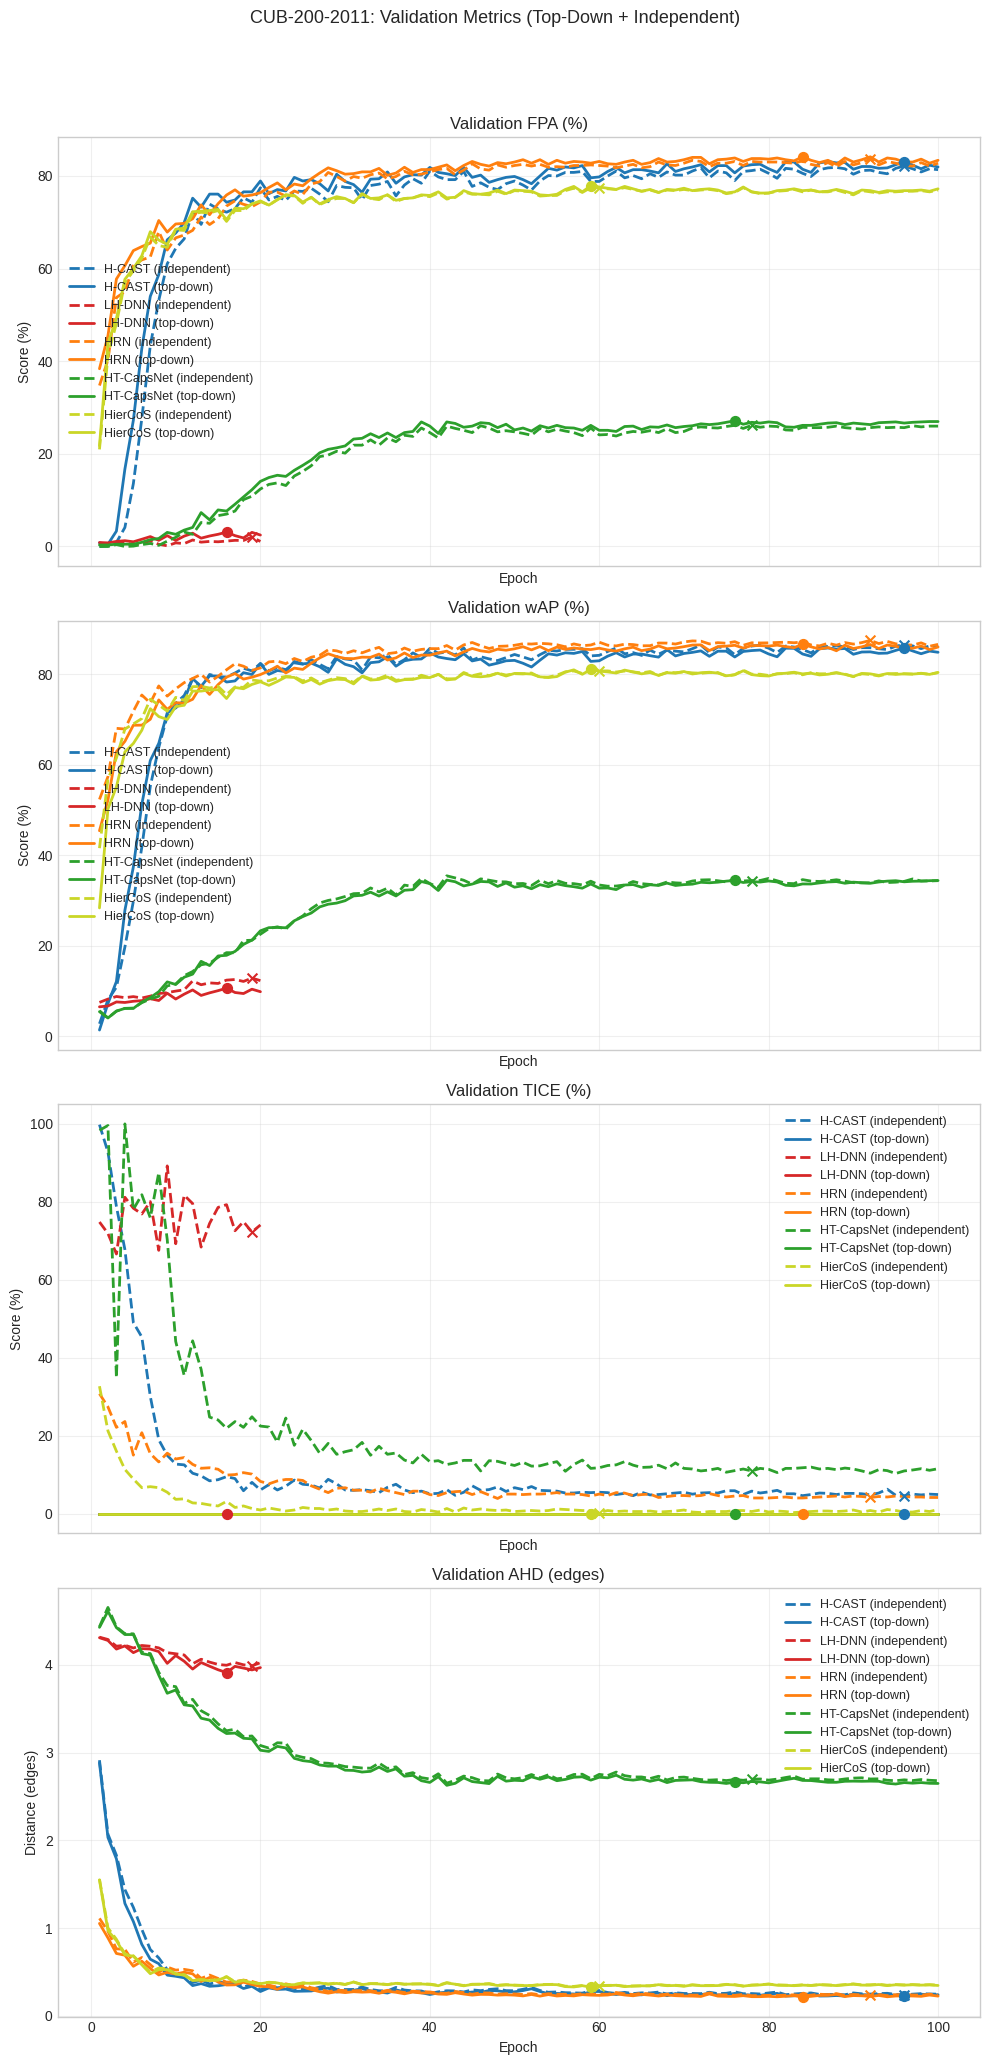

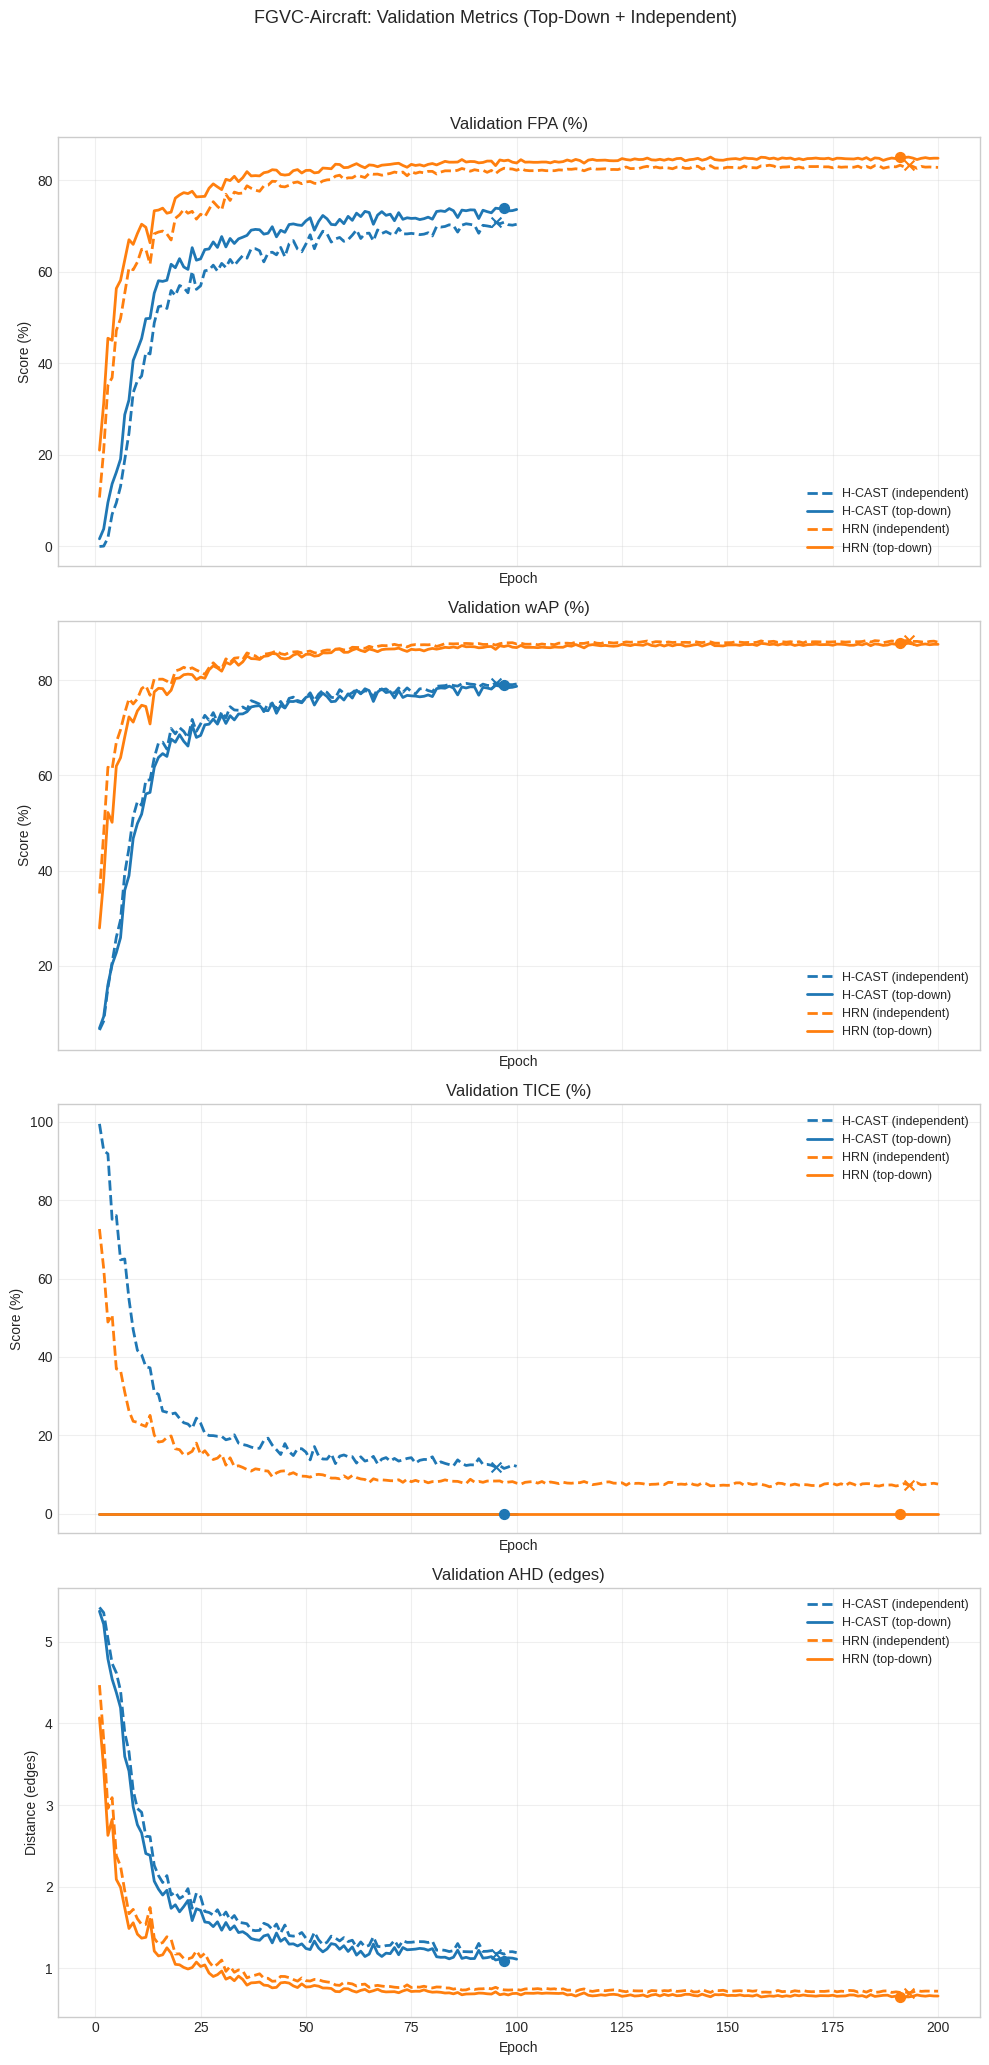

In [124]:
analysis.plot_validation_curves()


## Training Loss Comparison (Per Dataset)

Interpretation note:
- Lower is better for all loss curves.


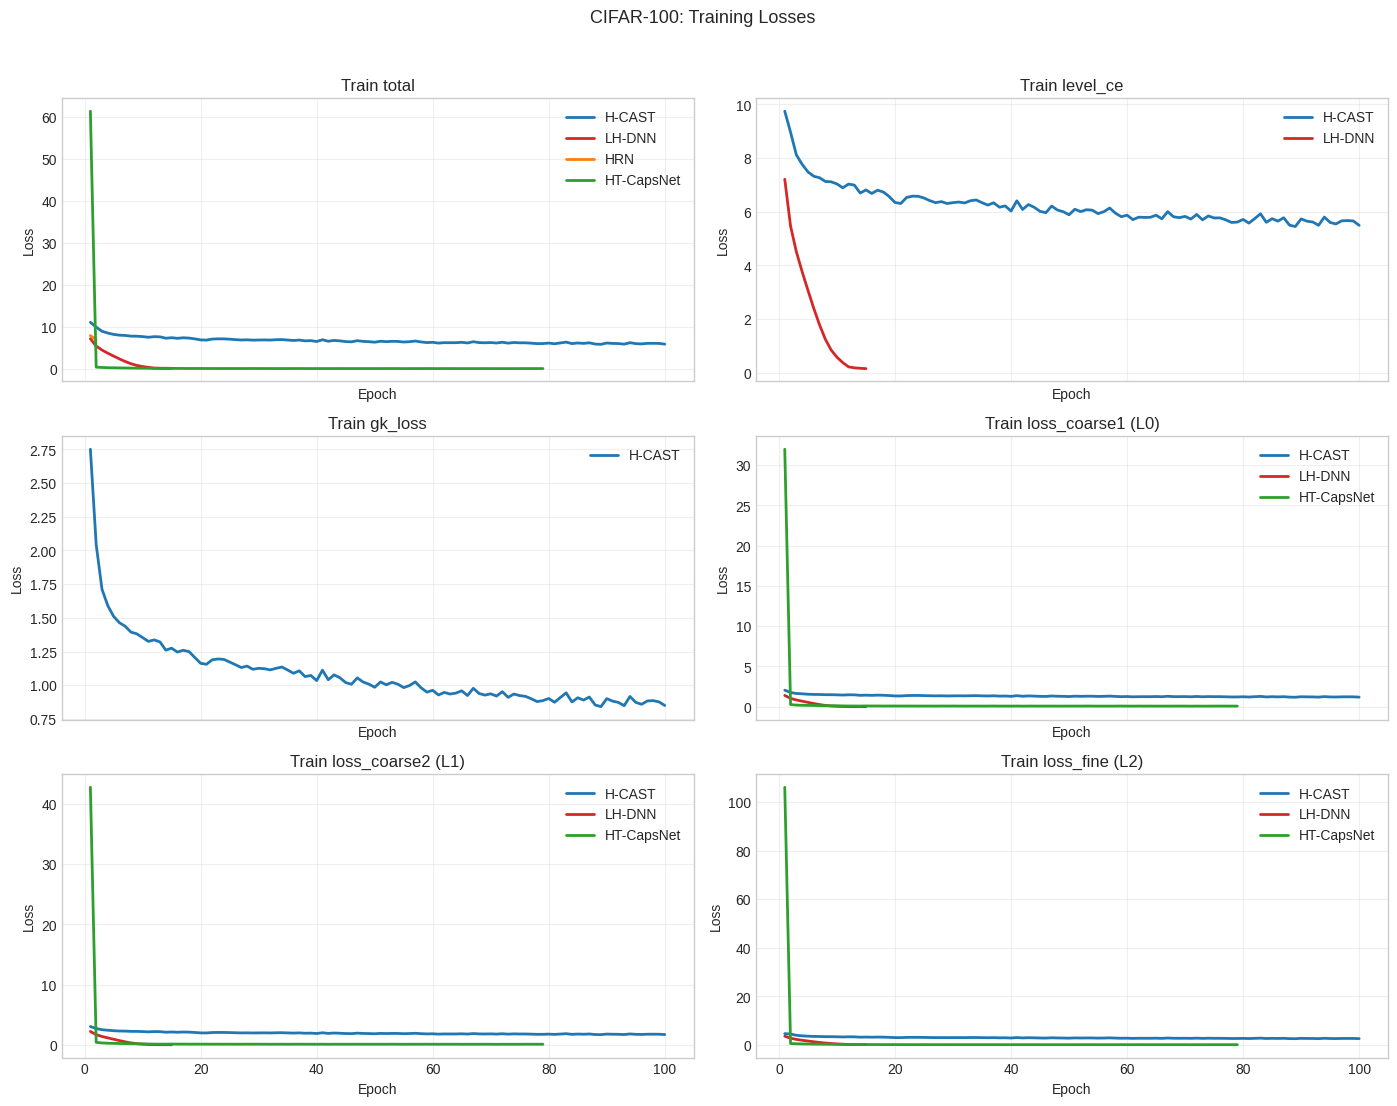

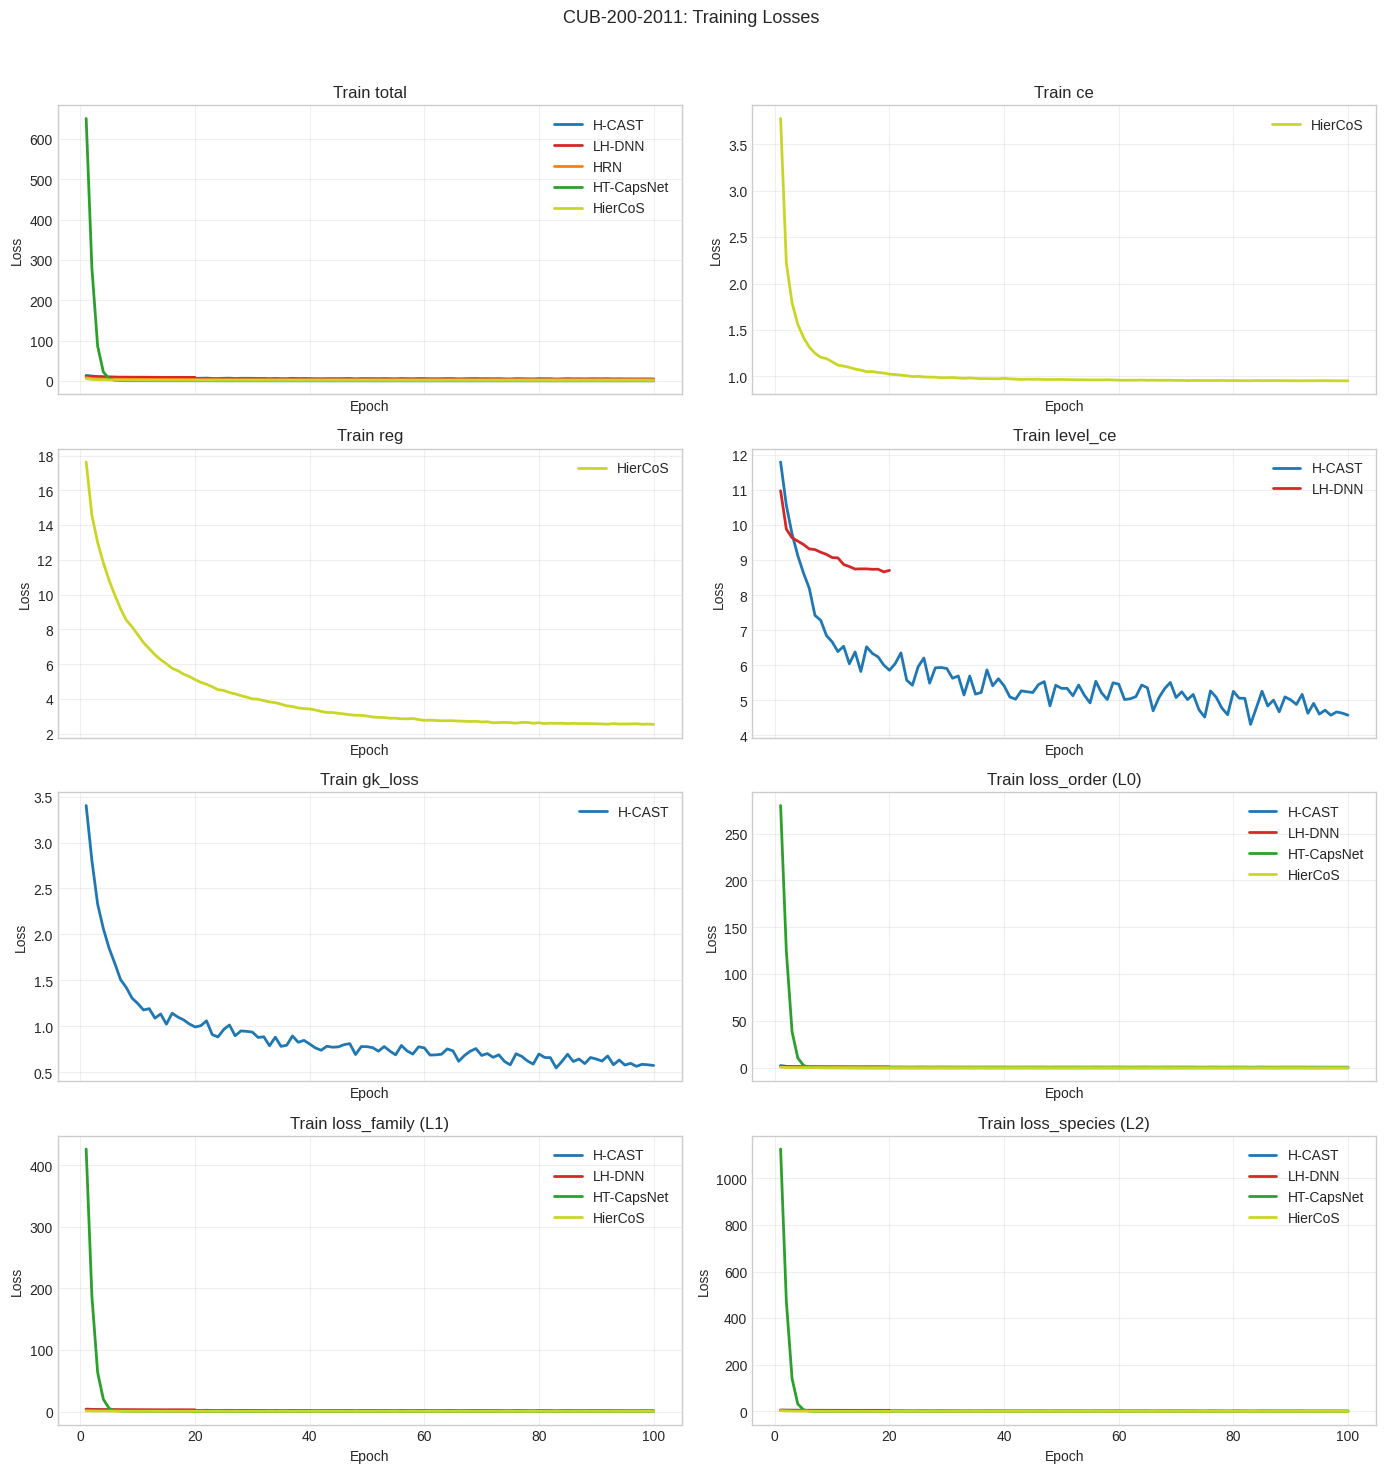

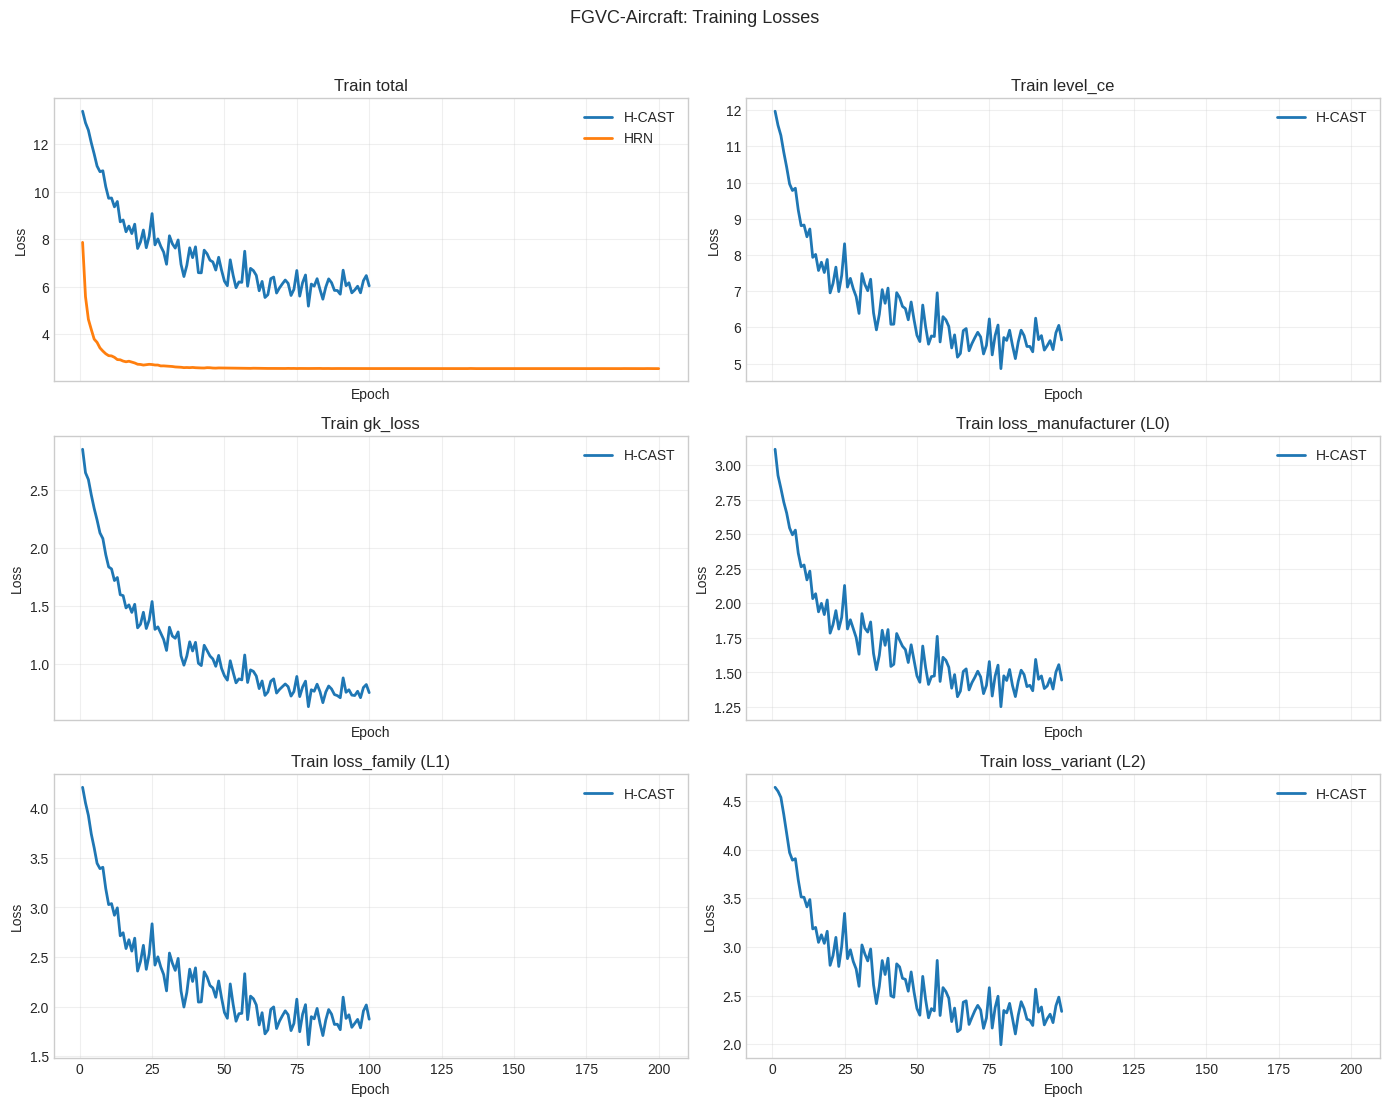

In [125]:
analysis.plot_training_losses_per_dataset()


## Per-Level Training Losses (Per Model and Dataset)

Interpretation note:
- Each chart corresponds to one selected `(model, dataset)` run.
- Lines in the same chart are all available `loss_level_*` training losses (lower is better).


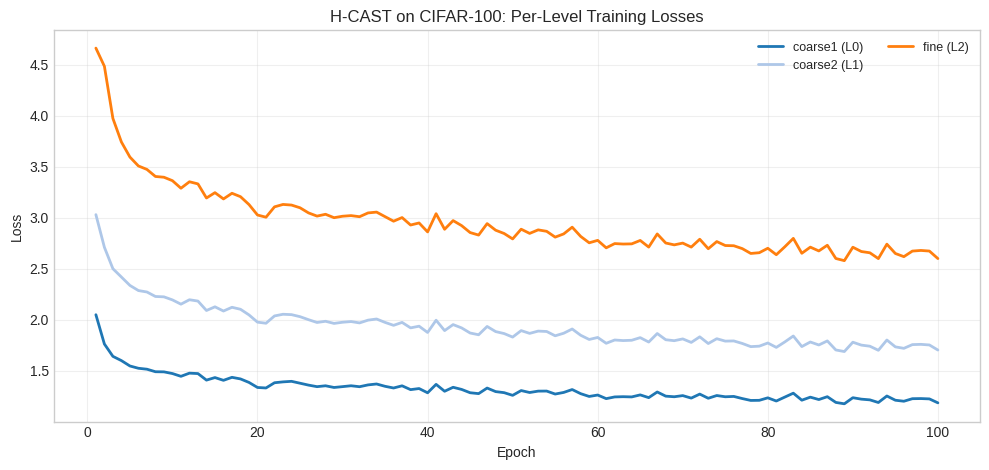

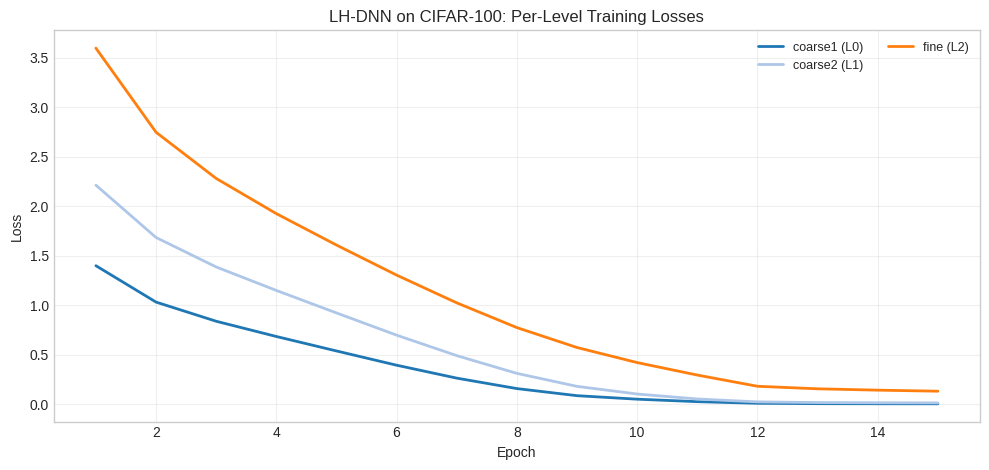

No per-level train losses for HRN on CIFAR-100


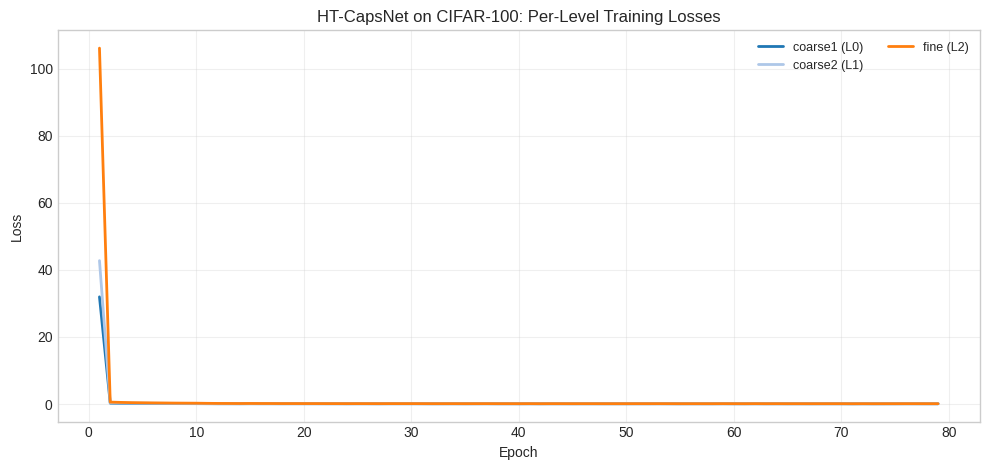

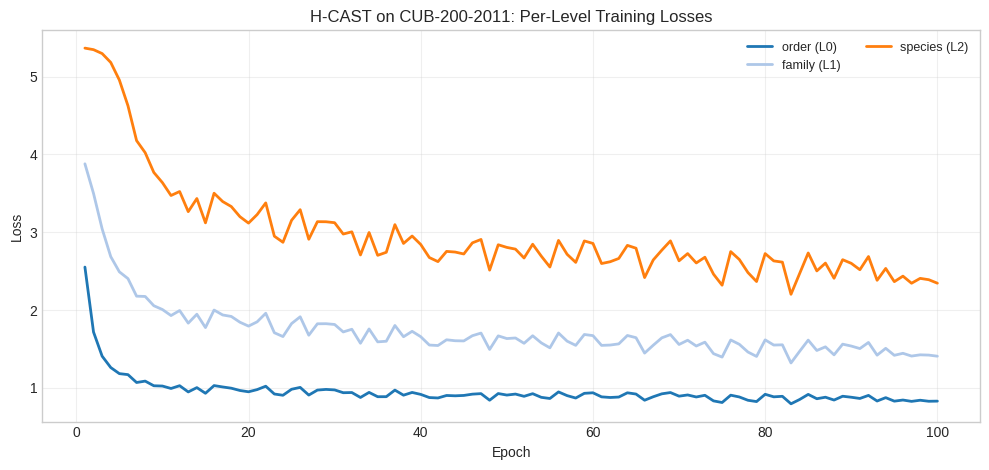

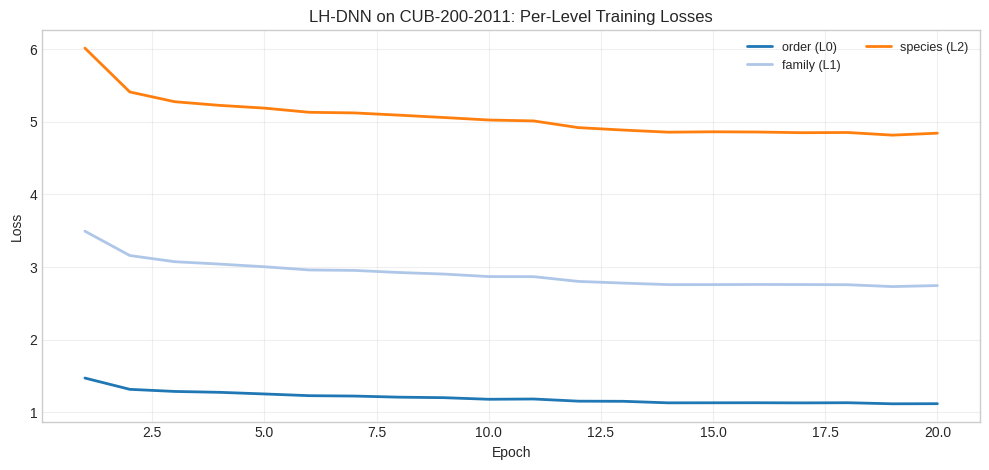

No per-level train losses for HRN on CUB-200-2011


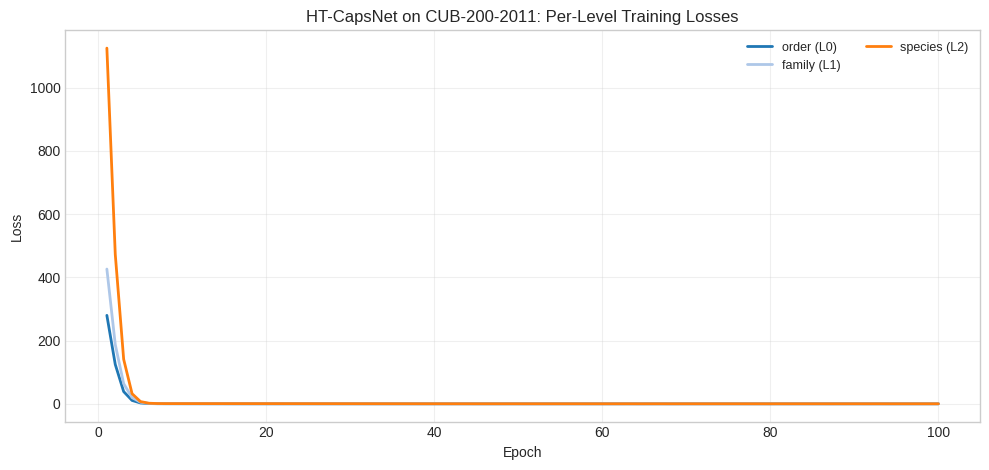

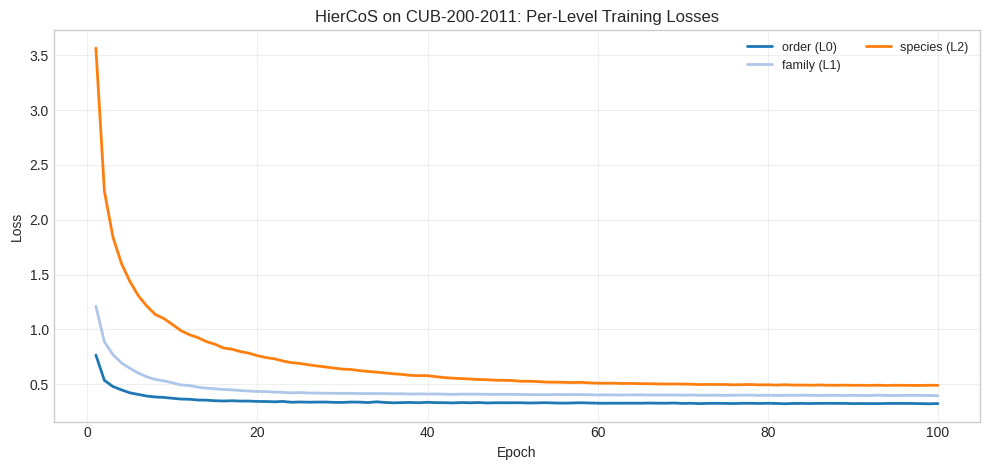

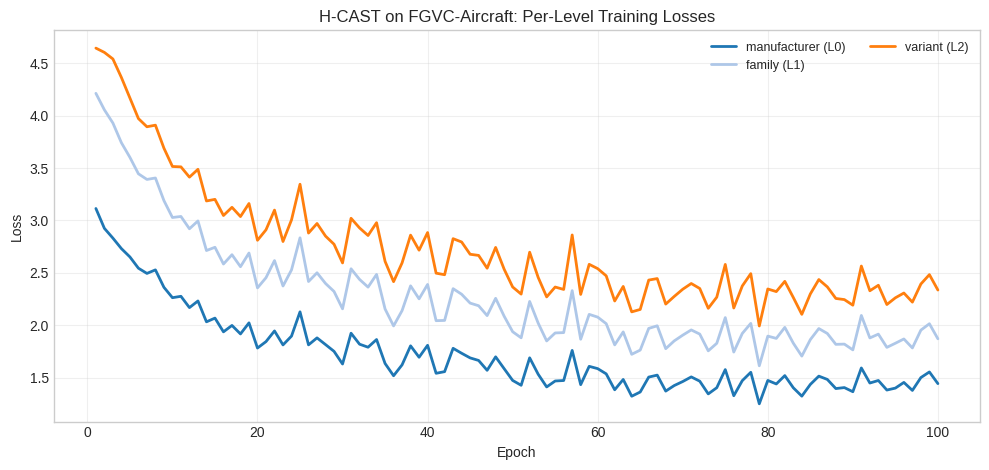

No per-level train losses for HRN on FGVC-Aircraft


In [126]:
analysis.plot_per_run_per_level_training_losses()


## Per-Level Validation Accuracy (Top-Down and Independent)

Interpretation note:
- Solid vs dashed of the same color shows top-down vs independent for the same model.


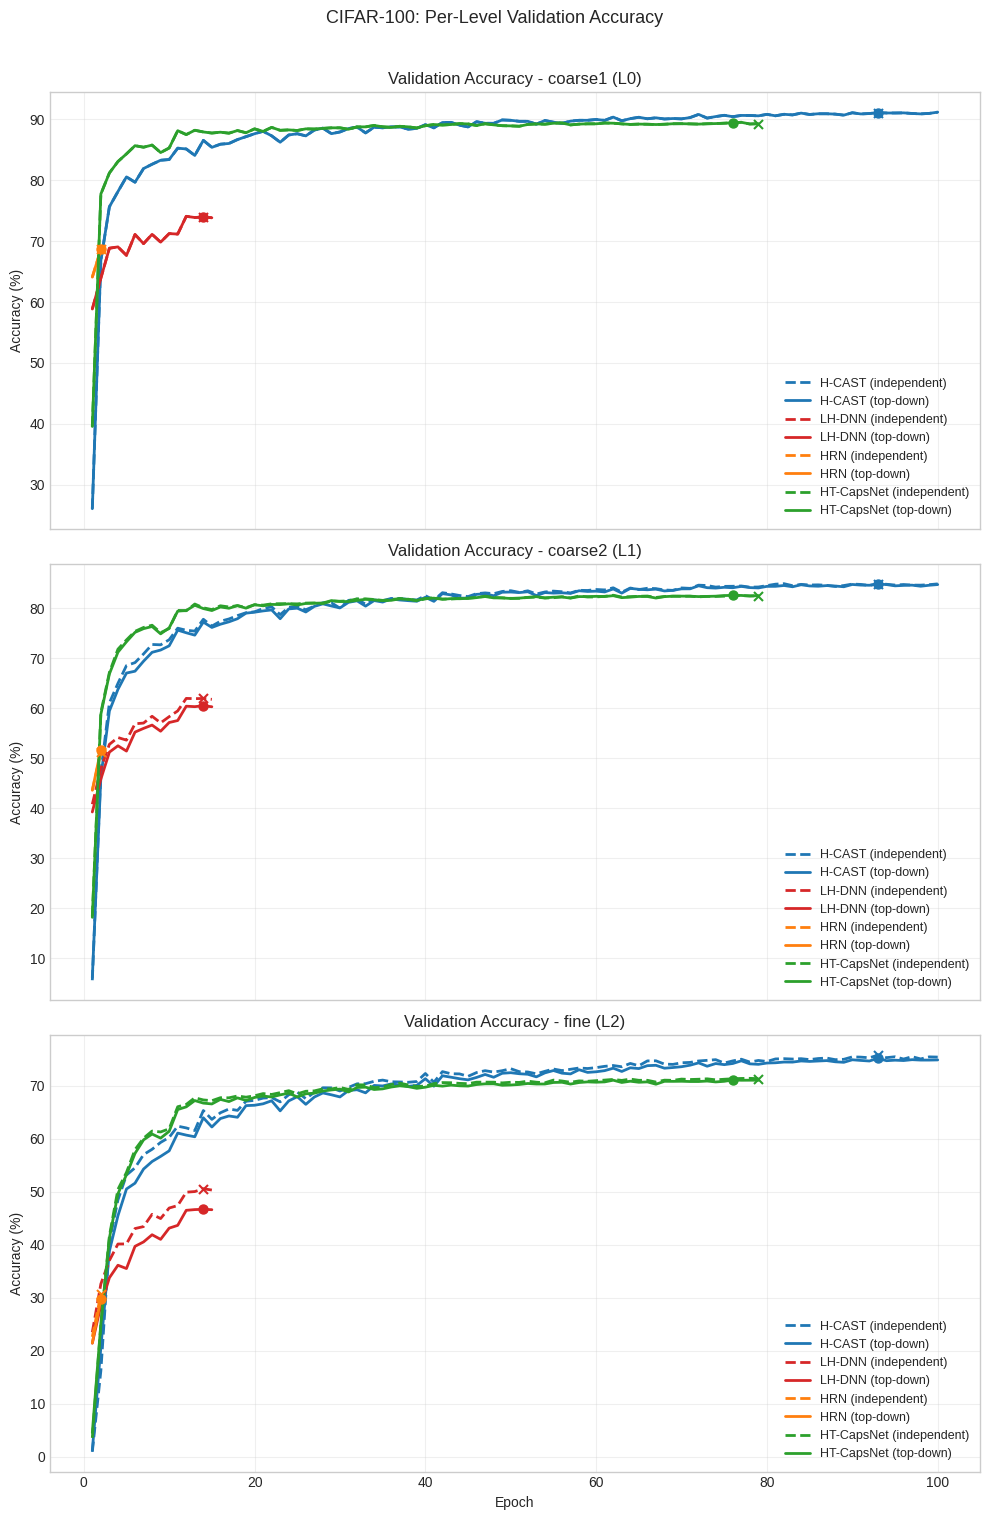

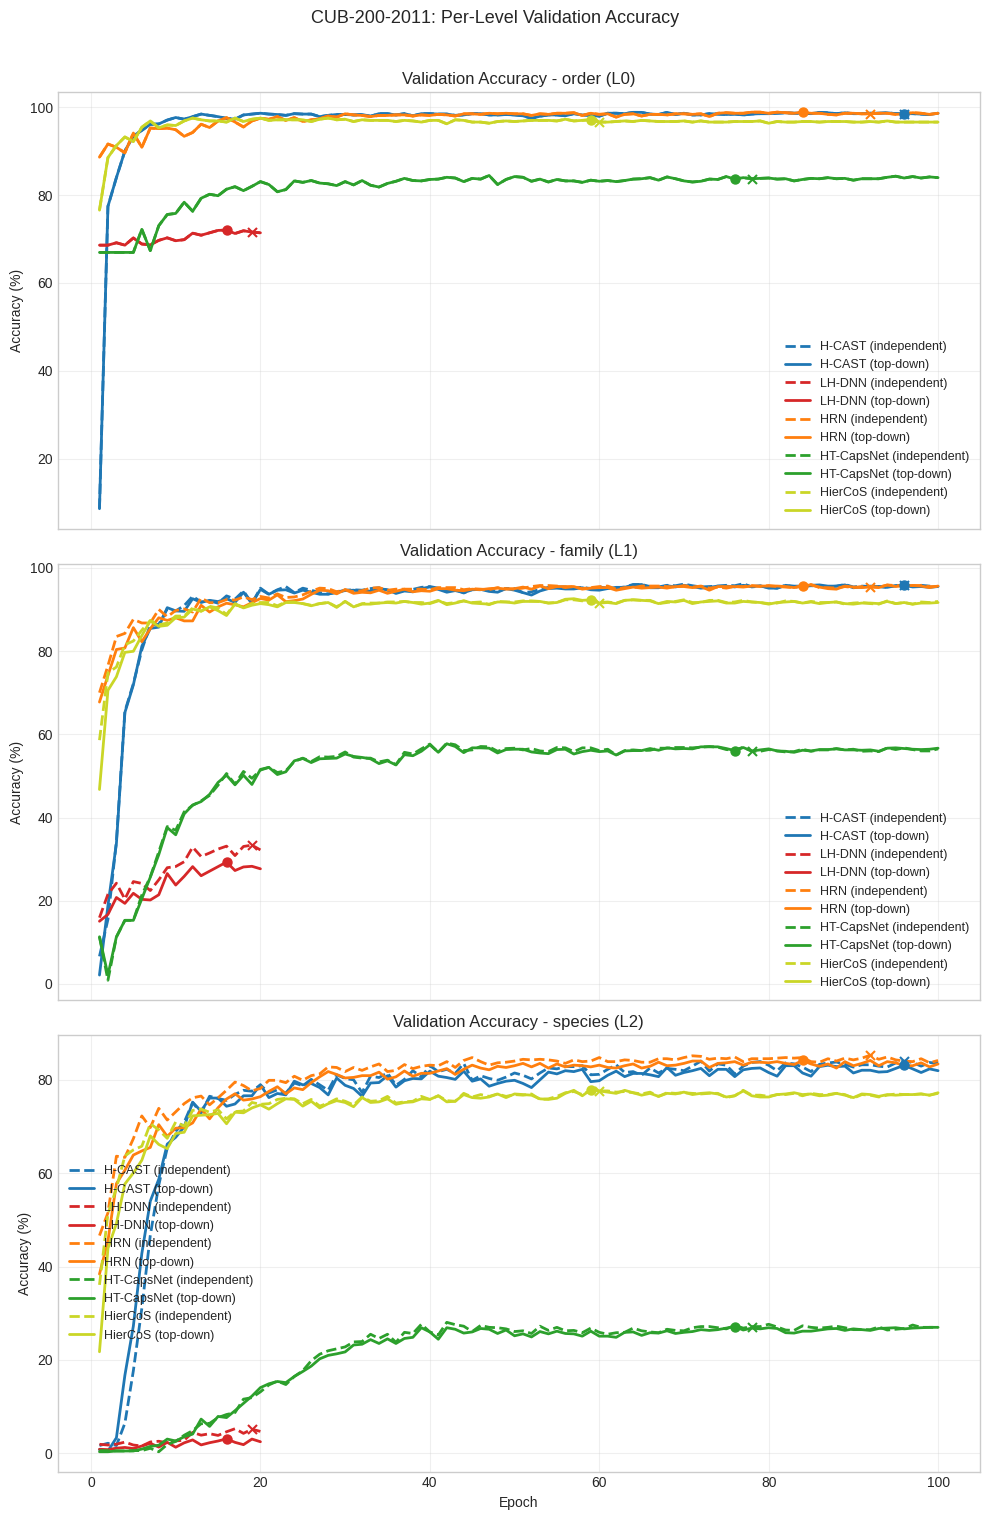

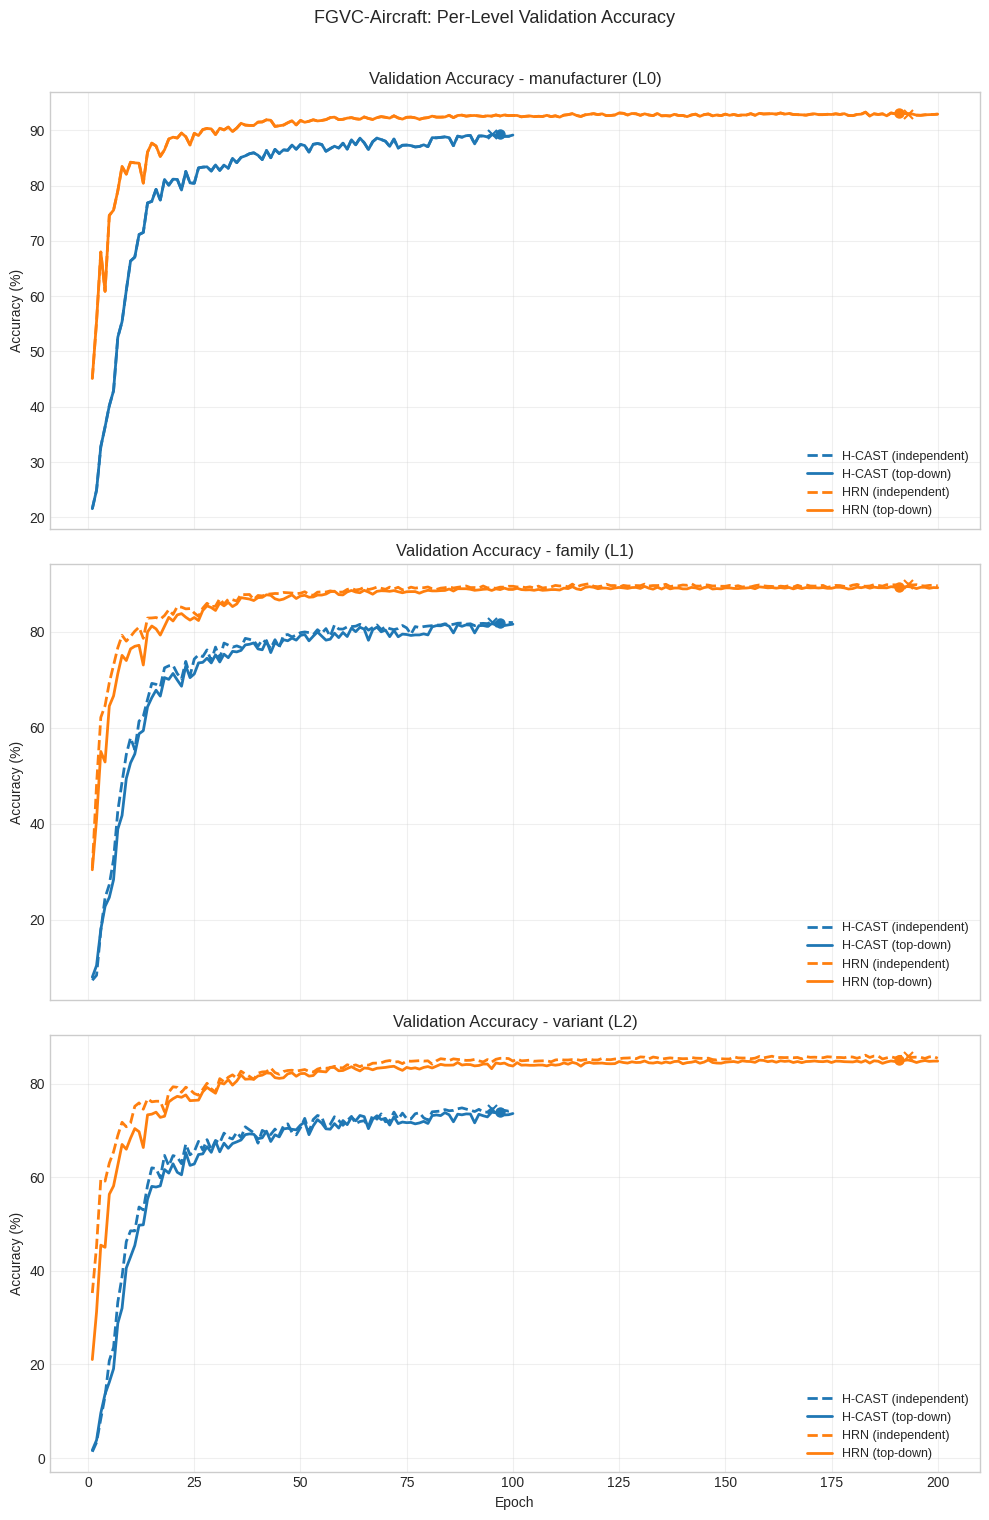

In [127]:
analysis.plot_per_level_validation_accuracy()


## Final Test Comparison Tables (Per Dataset)

The first model in each dataset section is used as baseline for deltas. When runs include mode-specific `test_results`, independent rows use the independent-best checkpoint and top-down rows use the top-down-best checkpoint.


In [128]:
analysis.show_final_test_tables()


### Dataset: `CIFAR-100`
Baseline run: **H-CAST**

| Metric | H-CAST | LH-DNN | HRN | HT-CapsNet |
|---|---:|---:|---:|---:|
| Best epoch (TD/Ind) | 93/93 | 14/14 | 2/2 | 76/79 |
| FPA independent ↑ | **72.39%** | <u>43.83% (-28.56 pp)</u> | n/a | n/a |
| FPA top-down ↑ | **74.28%** | <u>45.98% (-28.30 pp)</u> | n/a | n/a |
| wAP independent ↑ | **77.63%** | <u>53.16% (-24.46 pp)</u> | n/a | n/a |
| wAP top-down ↑ | **76.91%** | <u>49.84% (-27.06 pp)</u> | n/a | n/a |
| TICE independent ↓ | **8.32%** | <u>18.38% (+10.06 pp)</u> | n/a | n/a |
| TICE top-down ↓ | **0.00%** | **0.00% (+0.00 pp)** | n/a | n/a |
| AHD independent ↓ | **1.059** | <u>2.488 (+1.429)</u> | n/a | n/a |
| AHD top-down ↓ | **1.011** | <u>2.416 (+1.405)</u> | n/a | n/a |
| Acc independent coarse1 (L0) ↑ | **90.59%** | <u>73.51% (-17.08 pp)</u> | n/a | n/a |
| Acc top-down coarse1 (L0) ↑ | **90.59%** | <u>73.51% (-17.08 pp)</u> | n/a | n/a |
| Acc independent coarse2 (L1) ↑ | **84.59%** | <u>61.52% (-23.07 pp)</u> | n/a | n/a |
| Acc top-down coarse2 (L1) ↑ | **84.58%** | <u>59.71% (-24.87 pp)</u> | n/a | n/a |
| Acc independent fine (L2) ↑ | **75.20%** | <u>49.86% (-25.33 pp)</u> | n/a | n/a |
| Acc top-down fine (L2) ↑ | **74.28%** | <u>45.98% (-28.30 pp)</u> | n/a | n/a |

### Dataset: `CUB-200-2011`
Baseline run: **H-CAST**

| Metric | H-CAST | LH-DNN | HRN | HT-CapsNet | HierCoS |
|---|---:|---:|---:|---:|---:|
| Best epoch (TD/Ind) | 96/96 | 16/19 | 84/92 | 76/78 | 59/60 |
| FPA independent ↑ | <u>81.46%</u> | 1.66% (-79.80 pp) | **82.67% (+1.20 pp)** | 25.34% (-56.12 pp) | 76.48% (-4.99 pp) |
| FPA top-down ↑ | <u>82.92%</u> | 3.36% (-79.56 pp) | **84.31% (+1.38 pp)** | 26.30% (-56.62 pp) | 76.22% (-6.71 pp) |
| wAP independent ↑ | <u>85.65%</u> | 13.23% (-72.42 pp) | **86.95% (+1.30 pp)** | 34.24% (-51.41 pp) | 79.84% (-5.81 pp) |
| wAP top-down ↑ | <u>85.46%</u> | 11.04% (-74.42 pp) | **86.62% (+1.16 pp)** | 33.89% (-51.57 pp) | 79.49% (-5.97 pp) |
| TICE independent ↓ | 4.95% | 76.27% (+71.32 pp) | <u>4.83% (-0.12 pp)</u> | 11.80% (+6.85 pp) | **0.71% (-4.24 pp)** |
| TICE top-down ↓ | **0.00%** | **0.00% (+0.00 pp)** | **0.00% (+0.00 pp)** | **0.00% (+0.00 pp)** | **0.00% (+0.00 pp)** |
| AHD independent ↓ | <u>0.259</u> | 3.967 (+3.708) | **0.247 (-0.012)** | 2.689 (+2.429) | 0.356 (+0.097) |
| AHD top-down ↓ | <u>0.243</u> | 3.891 (+3.648) | **0.224 (-0.019)** | 2.660 (+2.417) | 0.361 (+0.118) |
| Acc independent order (L0) ↑ | <u>98.40%</u> | 71.23% (-27.17 pp) | **98.60% (+0.20 pp)** | 84.10% (-14.30 pp) | 97.12% (-1.29 pp) |
| Acc top-down order (L0) ↑ | <u>98.40%</u> | 71.23% (-27.17 pp) | **98.60% (+0.20 pp)** | 84.10% (-14.30 pp) | 96.91% (-1.49 pp) |
| Acc independent family (L1) ↑ | <u>94.50%</u> | 34.48% (-60.02 pp) | **94.54% (+0.05 pp)** | 56.75% (-37.75 pp) | 90.89% (-3.61 pp) |
| Acc top-down family (L1) ↑ | <u>94.40%</u> | 30.85% (-63.55 pp) | **94.68% (+0.29 pp)** | 56.61% (-37.79 pp) | 90.76% (-3.63 pp) |
| Acc independent species (L2) ↑ | <u>83.14%</u> | 5.42% (-77.72 pp) | **84.75% (+1.62 pp)** | 26.72% (-56.42 pp) | 76.61% (-6.52 pp) |
| Acc top-down species (L2) ↑ | <u>82.92%</u> | 3.36% (-79.56 pp) | **84.31% (+1.38 pp)** | 26.30% (-56.62 pp) | 76.22% (-6.71 pp) |

### Dataset: `FGVC-Aircraft`
Baseline run: **H-CAST**

| Metric | H-CAST | HRN |
|---|---:|---:|
| Best epoch (TD/Ind) | 97/95 | 191/193 |
| FPA independent ↑ | <u>69.24%</u> | **84.54% (+15.30 pp)** |
| FPA top-down ↑ | <u>72.31%</u> | **85.92% (+13.61 pp)** |
| wAP independent ↑ | <u>78.55%</u> | **89.37% (+10.81 pp)** |
| wAP top-down ↑ | <u>77.23%</u> | **88.78% (+11.55 pp)** |
| TICE independent ↓ | <u>13.68%</u> | **6.80% (-6.88 pp)** |
| TICE top-down ↓ | **0.00%** | **0.00% (+0.00 pp)** |
| AHD independent ↓ | <u>1.289</u> | **0.646 (-0.644)** |
| AHD top-down ↓ | <u>1.208</u> | **0.592 (-0.616)** |
| Acc independent manufacturer (L0) ↑ | <u>87.35%</u> | **93.57% (+6.22 pp)** |
| Acc top-down manufacturer (L0) ↑ | <u>87.38%</u> | **93.72% (+6.34 pp)** |
| Acc independent family (L1) ↑ | <u>81.38%</u> | **91.20% (+9.82 pp)** |
| Acc top-down family (L1) ↑ | <u>79.90%</u> | **90.75% (+10.85 pp)** |
| Acc independent variant (L2) ↑ | <u>73.93%</u> | **86.82% (+12.89 pp)** |
| Acc top-down variant (L2) ↑ | <u>72.31%</u> | **85.92% (+13.61 pp)** |